In [94]:
import matplotlib.pyplot as plt

In [95]:
# Example: Define J_k with predefined coverage sets
# J_k[k] = list of post indices j that can cover hotspot k
J_k = {
    0: [0, 2],  # Hotspot 0 can be covered by posts 0 and 2
    1: [1],     # Hotspot 1 can be covered by post 1
    2: [0, 1, 2] # Hotspot 2 can be covered by any post
}
print("J_k (predefined):", J_k)

J_k (predefined): {0: [0, 2], 1: [1], 2: [0, 1, 2]}


### Predefined Coverage Sets for Hotspots

In some scenarios, the set of ambulance posts that can cover each call hotspot ($J^{(*k)}$) is determined by policy, operational constraints, or historical data, rather than by a simple distance rule. In this case, you can define $J^{(*k)}$ as a dictionary where each hotspot $k$ maps to a list of post indices $j$ that are allowed to cover it.

This approach allows for maximum flexibility and can reflect real-world constraints or expert knowledge.

### Linear integer program

Let $I = \{0,\dots,\text{num\_ambulances}-1\}$ and $J = \{0,\dots,|\text{ambulance\_posts}|-1\}$ and $K = \{0,\dots,|\text{call\_hotspots}|-1\}$.

Decision variable:

- $x_{ij} \in \{0,1\}$, equal to 1 if ambulance $i$ is assigned to post $j$.
- $y_{k} \in \{0,1\}$, equal to 1 if call hotspot $k$ is "covered" by at least one ambulance (this is enforced by constraints).

Parameters:
- $c_{ij}$ cost of ambulanc $i$ moving to post $j$ (distance travelled but shift change cost)
- $b_{k}$ intensity of call hotspot (for example average number of calls during time period)

Objective:

$$
\min \sum_{i \in I} \sum_{j \in J} (c_{ij}) x_{ij} - \sum_{k \in K} (b_k) y_k
$$

Constraints

Each ambulance assigned once:

$$
\sum_{j \in J} x_{ij} = 1, \quad \forall i \in I
$$

Call hotspot covered constraint, where $J^{(*k)} \subseteq J$ is the subset $\{j \in J \text{ given ambulance post } j \text{ covers call hotspot k}  \}$:

$$
\sum_{j \in J^{(*k)}} x_{ij} \geq y_k, \quad \forall k \in K
$$


<!-- Optional post capacity / load balancing requirement constraint:

$$
\sum_{i \in I} x_{ij} \le U_j, \quad \forall j \in J
$$ -->

Possible to denote diminisihing award for coverage. For example assume $z_k$ is either 1 or 0. This constraint ensures it is $1$ only when there are at least 2 ambulances in the coverage spot:

$$
\sum_{j \in J^{(*k)}} x_{ij} \geq z_k - 1, \quad \forall k \in K
$$


In [96]:
import numpy as np
from scipy.optimize import milp, LinearConstraint, Bounds

def solve_ambulance_milp(num_ambulances, ambulance_posts, c, b, J_k):
    """
    Solve the ambulance post assignment MILP using scipy.optimize.milp.

    Variables (all binary):
      x[i][j]  – ambulance i assigned to post j   (index: i*num_posts + j)
      y[k]     – hotspot k is covered              (index: n_x + k)

    Objective: min  sum c[i][j]*x[i][j]  -  sum b[k]*y[k]

    Returns: list of (ambulance_index, post_index) assignments
    """
    num_posts    = len(ambulance_posts)
    num_hotspots = len(b)
    n_x          = num_ambulances * num_posts
    n_vars       = n_x + num_hotspots

    # ── Objective ────────────────────────────────────────────────────────────
    c_obj = np.zeros(n_vars)
    for i in range(num_ambulances):
        for j in range(num_posts):
            c_obj[i * num_posts + j] = c[i][j]
    for k in range(num_hotspots):
        c_obj[n_x + k] = -b[k]

    # ── Constraints ──────────────────────────────────────────────────────────
    rows, lbs, ubs = [], [], []

    # Each ambulance assigned to exactly one post: sum_j x[i][j] = 1
    for i in range(num_ambulances):
        row = np.zeros(n_vars)
        for j in range(num_posts):
            row[i * num_posts + j] = 1.0
        rows.append(row); lbs.append(1.0); ubs.append(1.0)

    # Coverage: sum_{i, j in J_k[k]} x[i][j] - y[k] >= 0
    for k in range(num_hotspots):
        covering = J_k.get(k, [])
        row = np.zeros(n_vars)
        for i in range(num_ambulances):
            for j in covering:
                row[i * num_posts + j] = 1.0
        row[n_x + k] = -1.0
        rows.append(row); lbs.append(0.0); ubs.append(np.inf)

    constraints  = LinearConstraint(np.array(rows), lbs, ubs)
    bounds       = Bounds(lb=0, ub=1)
    integrality  = np.ones(n_vars)   # all binary

    result = milp(c_obj, constraints=constraints, integrality=integrality, bounds=bounds)
    if not result.success:
        raise RuntimeError(f"MILP solver failed: {result.message}")

    x_vals = result.x[:n_x].reshape(num_ambulances, num_posts)
    return [(i, j)
            for i in range(num_ambulances)
            for j in range(num_posts)
            if x_vals[i, j] > 0.5]

In [97]:
hosptials = [(0,0), (0,10), (10,10), (10,0)]
ambulance_posts = [(0, 3), (10, 7), (1, 10)]
call_hotspots = [(0, 4), (9, 8), (2, 10)]
num_ambulances = 5
b = [8, 6, 10]

# J_k[k] = list of post indices j that can cover hotspot k
J_k = {
    0: [0],
    1: [1],
    2: [2],
}

In [98]:
import math

def euclidean_distance(a, b):
    return math.dist(a, b)


print("b =", b)
print("J_k =", J_k)

b = [8, 6, 10]
J_k = {0: [0], 1: [1], 2: [2]}


In [99]:
from collections import defaultdict
def plot_assignments_with_table(ambulance_posts, call_hotspots, assignments, num_ambulances, print_details=True):
    plt.figure(figsize=(8, 8))
    # Plot ambulance posts
    for idx, post in enumerate(ambulance_posts):
        plt.scatter(post[0], post[1], c='blue', marker='s', s=100, label='Ambulance Post' if idx == 0 else "")
        plt.text(post[0]+0.1, post[1]+0.1, f'P{idx}', color='blue')
    # Plot call hotspots
    for idx, hotspot in enumerate(call_hotspots):
        plt.scatter(hotspot[0], hotspot[1], c='red', marker='*', s=150, label='Hotspot' if idx == 0 else "")
        plt.text(hotspot[0]+0.1, hotspot[1]+0.1, f'H{idx}', color='red')
    # Plot ambulances as lighter green triangles at their assigned posts
    assigned_posts = [post for _, post in assignments]
    for amb_idx, post_idx in enumerate(assigned_posts):
        post = ambulance_posts[post_idx]
        plt.scatter(post[0], post[1], c='#90ee90', marker='^', s=120, label='Ambulance' if amb_idx == 0 else "")
        plt.text(post[0]-0.2, post[1]-0.2, f'A{amb_idx}', color='#228B22')
    plt.legend()
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Ambulance Posts, Hotspots, and Assignments')
    plt.grid(True)
    plt.show()
    # Create a summary dictionary of assignments indexed by post
    post_to_ambulances = defaultdict(list)
    for amb, post in assignments:
        post_to_ambulances[post].append(amb)
    if print_details:
        print("Ambulance assignments by post:")
        for post_idx in range(len(ambulance_posts)):
            loc = ambulance_posts[post_idx]
            assigned_ambs = post_to_ambulances.get(post_idx, [])
            print(f"Post {post_idx} at {loc}: {assigned_ambs if assigned_ambs else 'No ambulances assigned'}")
    return dict(post_to_ambulances)

In [100]:
import math
def calculate_c(ambulance_assignments, ambulance_posts, t):
    """
    Calculate c values for each ambulance and post at timestep t.
    ambulance_assignments: list of current post indices for each ambulance (len=num_ambulances)
    ambulance_posts: list of post locations [(x, y), ...]
    t: current timestep (not used in this simple version, but included for future extension)
    Returns: c as a 2D list, where c[i][j] is the distance from ambulance i's current post to post j
    """
    num_ambulances = len(ambulance_assignments)
    num_posts = len(ambulance_posts)
    c = []
    for i in range(num_ambulances):
        current_post = ambulance_assignments[i]
        current_loc = ambulance_posts[current_post]
        row = []
        for j in range(num_posts):
            target_loc = ambulance_posts[j]
            dist = math.dist(current_loc, target_loc)
            row.append(dist)
        c.append(row)
    return c

def calculate_b(ambulance_assignments, ambulance_posts, t):
    """
    Hardcoded b values for 5 hospitals and 5 hotspots, ignoring inputs.
    Returns: b as a list of length 5.
    """
    # Example hardcoded values (can be changed as needed)
    b = [
        [0, 1, 0, 1, 1],
        [1, 1, 1, 1, 1],
        [19, 1, 10, 1, 1],
        [20, 1, 20, 1, 1],
        [0, 0, 20, 40, 20],
    ]

    return b[t % 5]  # Just return a row based on timestep for demonstration

## Gaussian Hotspot Intensity Model

Instead of hardcoded `b` values, we model call intensity across the map as a sum of Gaussian PDFs sampled at a dense grid of coordinates. The grid points become the call hotspots, and each hotspot's intensity `b[k]` is the summed PDF value at that location.

Two configurations are supported:
- **Even timesteps**: 2 Gaussians placed at opposite corners of the map
- **Odd timesteps**: 3 Gaussians placed at the vertices of an equilateral triangle

`create_gaussian_field(sample_points, gaussian_params)` is the core function — it takes in pre-generated sample coordinates and a list of `(mean, std)` Gaussian parameters, returning one intensity value per point.

`calculate_b_gaussian` wraps this, selecting the appropriate Gaussian layout based on the timestep.

In [101]:
import numpy as np
from scipy.stats import multivariate_normal

def make_grid_points(map_bounds, grid_step=1):
    """
    Generate a regular grid of (x, y) sample points.
    map_bounds: (x_min, x_max, y_min, y_max)
    grid_step: spacing between points
    """
    x_min, x_max, y_min, y_max = map_bounds
    xs = np.arange(x_min, x_max + grid_step, grid_step)
    ys = np.arange(y_min, y_max + grid_step, grid_step)
    return [(float(x), float(y)) for x in xs for y in ys]


def create_gaussian_field(sample_points, gaussian_params):
    """
    Evaluate a sum of isotropic Gaussian PDFs at each sample point.

    sample_points: list of (x, y) coordinates to evaluate
    gaussian_params: list of ([mean_x, mean_y], std) tuples

    Returns: list of float intensities, one per sample point
    """
    pts = np.array(sample_points)
    intensities = np.zeros(len(sample_points))
    for mean, std in gaussian_params:
        rv = multivariate_normal(mean=mean, cov=std ** 2 * np.eye(2))
        intensities += rv.pdf(pts)
    return intensities


def calculate_b_gaussian(ambulance_posts, t, sample_points, map_bounds):
    """
    Return b (intensity list) for each sample point at timestep t.

    Uses match/case with modulo 4:
    - Case 0: 2 Gaussians at opposite corners
    - Case 1: 3 Gaussians at equilateral triangle vertices
    - Case 2: 2 Gaussians with randomized means and stds (fixed seed)
    - Case 3: 3 Gaussians with randomized means and stds (fixed seed)

    ambulance_posts: list of (x, y) post locations
    t: timestep index
    sample_points: pre-generated list of (x, y) coordinates to evaluate
    map_bounds: (x_min, x_max, y_min, y_max)
    """
    x_min, x_max, y_min, y_max = map_bounds
    cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2
    r = min(x_max - x_min, y_max - y_min) * 0.35
    std = r / 2.5

    case = t % 4

    match case:
        case 0:
            # Two Gaussians at opposite corners (deterministic)
            gaussian_params = [
                ([x_min + r * 0.6, y_min + r * 0.6], std),
                ([x_max - r * 0.6, y_max - r * 0.6], std),
            ]

        case 1:
            # Three Gaussians at equilateral triangle vertices (deterministic)
            gaussian_params = [
                (
                    [cx + r * np.cos(np.pi / 2 + 2 * np.pi * k / 3),
                     cy + r * np.sin(np.pi / 2 + 2 * np.pi * k / 3)],
                    std,
                )
                for k in range(3)
            ]

        case 2:
            # Two Gaussians with randomized means and stds (fixed seed)
            rng = np.random.default_rng(seed=2024)
            means = [
                [x_min + rng.uniform(0, r), y_min + rng.uniform(0, r)],
                [x_max - rng.uniform(0, r), y_max - rng.uniform(0, r)],
            ]
            stds = [rng.uniform(std * 0.5, std * 1.5) for _ in range(2)]
            gaussian_params = list(zip(means, stds))

        case 3:
            # Three Gaussians with randomized means and stds (fixed seed)
            rng = np.random.default_rng(seed=2025)
            means = [
                [cx + rng.uniform(-r, r), cy + rng.uniform(-r, r)]
                for _ in range(3)
            ]
            stds = [rng.uniform(std * 0.5, std * 1.5) for _ in range(3)]
            gaussian_params = list(zip(means, stds))

    return create_gaussian_field(sample_points, gaussian_params) * 100 # Scale to make values more comparable to 

## Simulation Example: 10 Hospitals, 10 Ambulance Posts, 10 Hotspots
Ten hospitals are placed on a circle of radius 15. Ten ambulance posts are co-located with the hospitals, and ten call hotspots are offset slightly from each post. The coverage set $J_k$ assigns hotspot $k$ exclusively to post $k$.

In [102]:
def run_simulation(num_timesteps, num_ambulances, ambulance_posts, call_hotspots, J_k, calculate_c_fn, calculate_b_fn, show_hotspots=True):
    """
    Runs a simulation for num_timesteps, updating assignments and displaying plots for each timestep.
    ambulance_posts:  list of post locations [(x, y), ...]
    call_hotspots:    list of hotspot locations [(x, y), ...]
    J_k:              dict mapping hotspot index → list of post indices that cover it
    calculate_c_fn:   (ambulance_assignments, ambulance_posts, t) → 2-D cost list
    calculate_b_fn:   (ambulance_assignments, ambulance_posts, t) → intensity list
    show_hotspots:    if True, plot hotspots; if False, omit them (default: True)
    """
    assignments_history = []
    ambulance_assignments = None
    plot_data = []

    for t in range(num_timesteps):
        if t == 0:
            c = [[0] * len(ambulance_posts) for _ in range(num_ambulances)]
        else:
            c = calculate_c_fn(ambulance_assignments, ambulance_posts, t)

        b = calculate_b_fn(
            [0] * num_ambulances if t == 0 else ambulance_assignments,
            ambulance_posts, t
        )

        assignments = solve_ambulance_milp(num_ambulances, ambulance_posts, c, b, J_k)
        ambulance_assignments = [j for _, j in assignments]
        assignments_history.append(assignments)
        plot_data.append((ambulance_posts, call_hotspots, assignments, num_ambulances, t))

    # ── Plot all timesteps in a 2-column grid ────────────────────────────────
    num_cols = 2
    num_rows = (num_timesteps + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(8 * num_cols, 8 * num_rows))
    axes = axes.flatten()

    for idx, (posts, hotspots, asgn, n_amb, t) in enumerate(plot_data):
        ax = axes[idx]
        for p_idx, post in enumerate(posts):
            ax.scatter(post[0], post[1], c='blue', marker='s', s=100,
                       label='Ambulance Post' if p_idx == 0 else "")
            ax.text(post[0] + 0.3, post[1] + 0.3, f'P{p_idx}', color='blue', fontsize=7)
        
        if show_hotspots:
            for h_idx, hotspot in enumerate(hotspots):
                ax.scatter(hotspot[0], hotspot[1], c='red', marker='*', s=150,
                           label='Hotspot' if h_idx == 0 else "")
                ax.text(hotspot[0] + 0.3, hotspot[1] + 0.3, f'H{h_idx}', color='red', fontsize=7)
        
        for amb_idx, post_idx in [a for a in asgn]:
            post = posts[post_idx]
            ax.scatter(post[0], post[1], c='#00AA00', marker='^', s=200,
                       label='Ambulance' if amb_idx == 0 else "", edgecolors='darkgreen', linewidth=1.5)
            ax.text(post[0] - 0.6, post[1] - 0.6, f'A{amb_idx}', color='white', fontsize=9, 
                   weight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='darkgreen', alpha=0.8))
        ax.set_xlabel('X'); ax.set_ylabel('Y')
        ax.set_title(f'Timestep {t}')
        ax.grid(True)
        if idx == 0:
            ax.legend()

    for idx in range(len(plot_data), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()
    return assignments_history

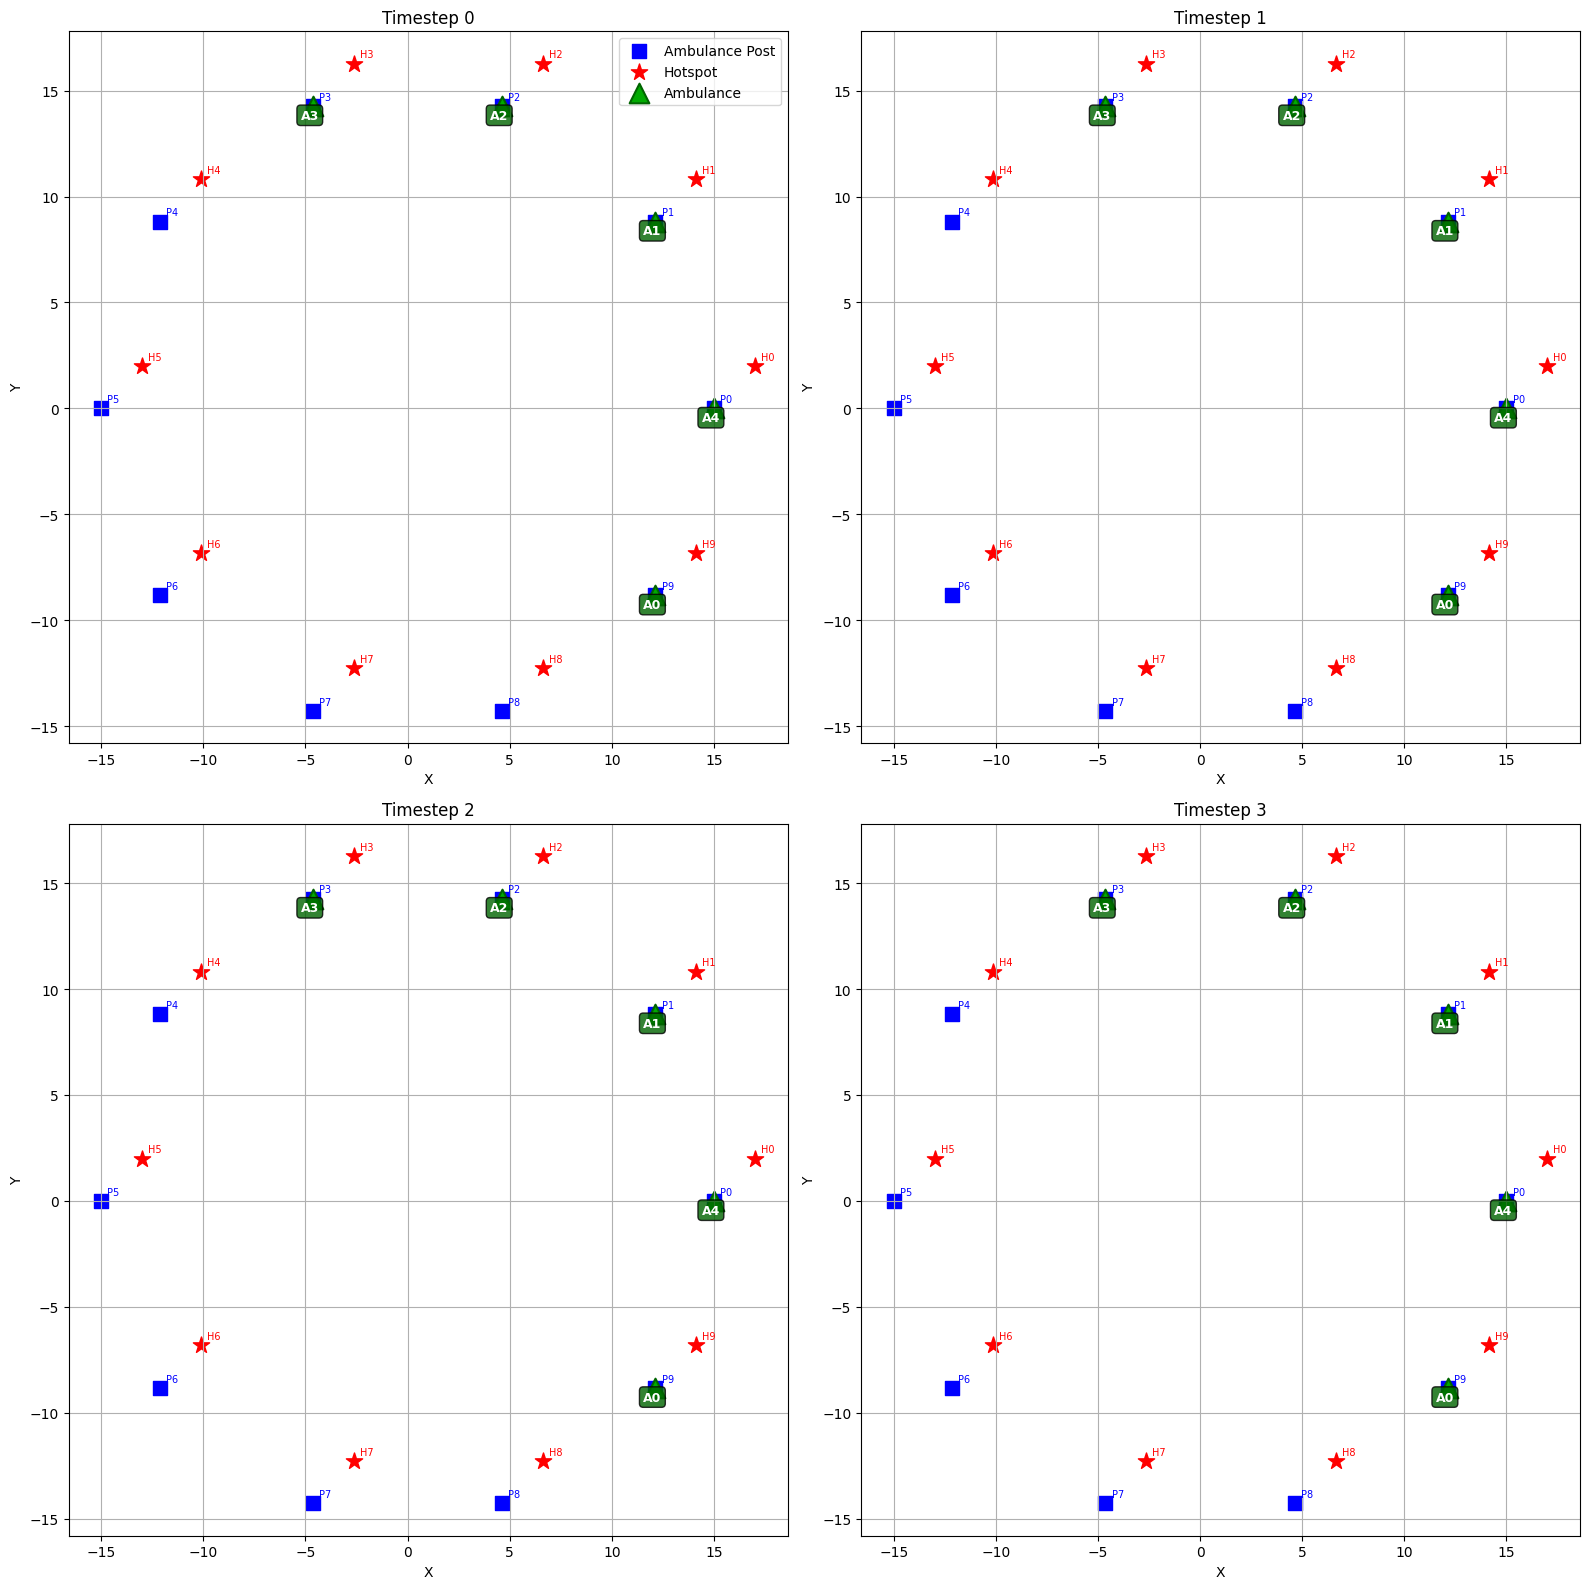

In [103]:
import math

def polygon_vertices(n, center, radius):
    """Return n evenly-spaced vertices of a regular polygon on a circle."""
    angles = np.linspace(0, 2 * np.pi, n + 1)[:-1]
    return [(center[0] + radius * np.cos(a), center[1] + radius * np.sin(a)) for a in angles]

NUM_HOSPITALS = 10
center = (0, 0)
radius = 15

hospitals        = polygon_vertices(NUM_HOSPITALS, center, radius)
ambulance_posts  = hospitals.copy()

hotspot_offset = 2
call_hotspots  = [(x + hotspot_offset, y + hotspot_offset) for x, y in ambulance_posts]

# J_k: hotspot k covered only by post k
J_k = {k: [k] for k in range(NUM_HOSPITALS)}

def calculate_b_decagon(ambulance_assignments, ambulance_posts, t):
    """Simple cycling b values for 10 hotspots."""
    rng = np.random.default_rng(seed=t)
    return rng.integers(1, 20, size=NUM_HOSPITALS).tolist()

assignment_history = run_simulation(
    num_timesteps=4,
    num_ambulances=5,
    ambulance_posts=ambulance_posts,
    call_hotspots=call_hotspots,
    J_k=J_k,
    calculate_c_fn=calculate_c,
    calculate_b_fn=calculate_b_decagon,
)

In [104]:
assignment_history

[[(0, 9), (1, 1), (2, 2), (3, 3), (4, 0)],
 [(0, 9), (1, 1), (2, 2), (3, 3), (4, 0)],
 [(0, 9), (1, 1), (2, 2), (3, 3), (4, 0)],
 [(0, 9), (1, 1), (2, 2), (3, 3), (4, 0)]]

## Simulation with Gaussian Hotspot Intensities

Using the 10-hospital decagon layout. Hotspots are now a dense grid of points sampled every 1 unit across the map. `b[k]` is the Gaussian intensity at each grid point, and `J_k` assigns each grid point to its nearest ambulance post.

The intensity field shifts between timesteps: opposite-corner mode (even $t$) vs. equilateral-triangle mode (odd $t$).

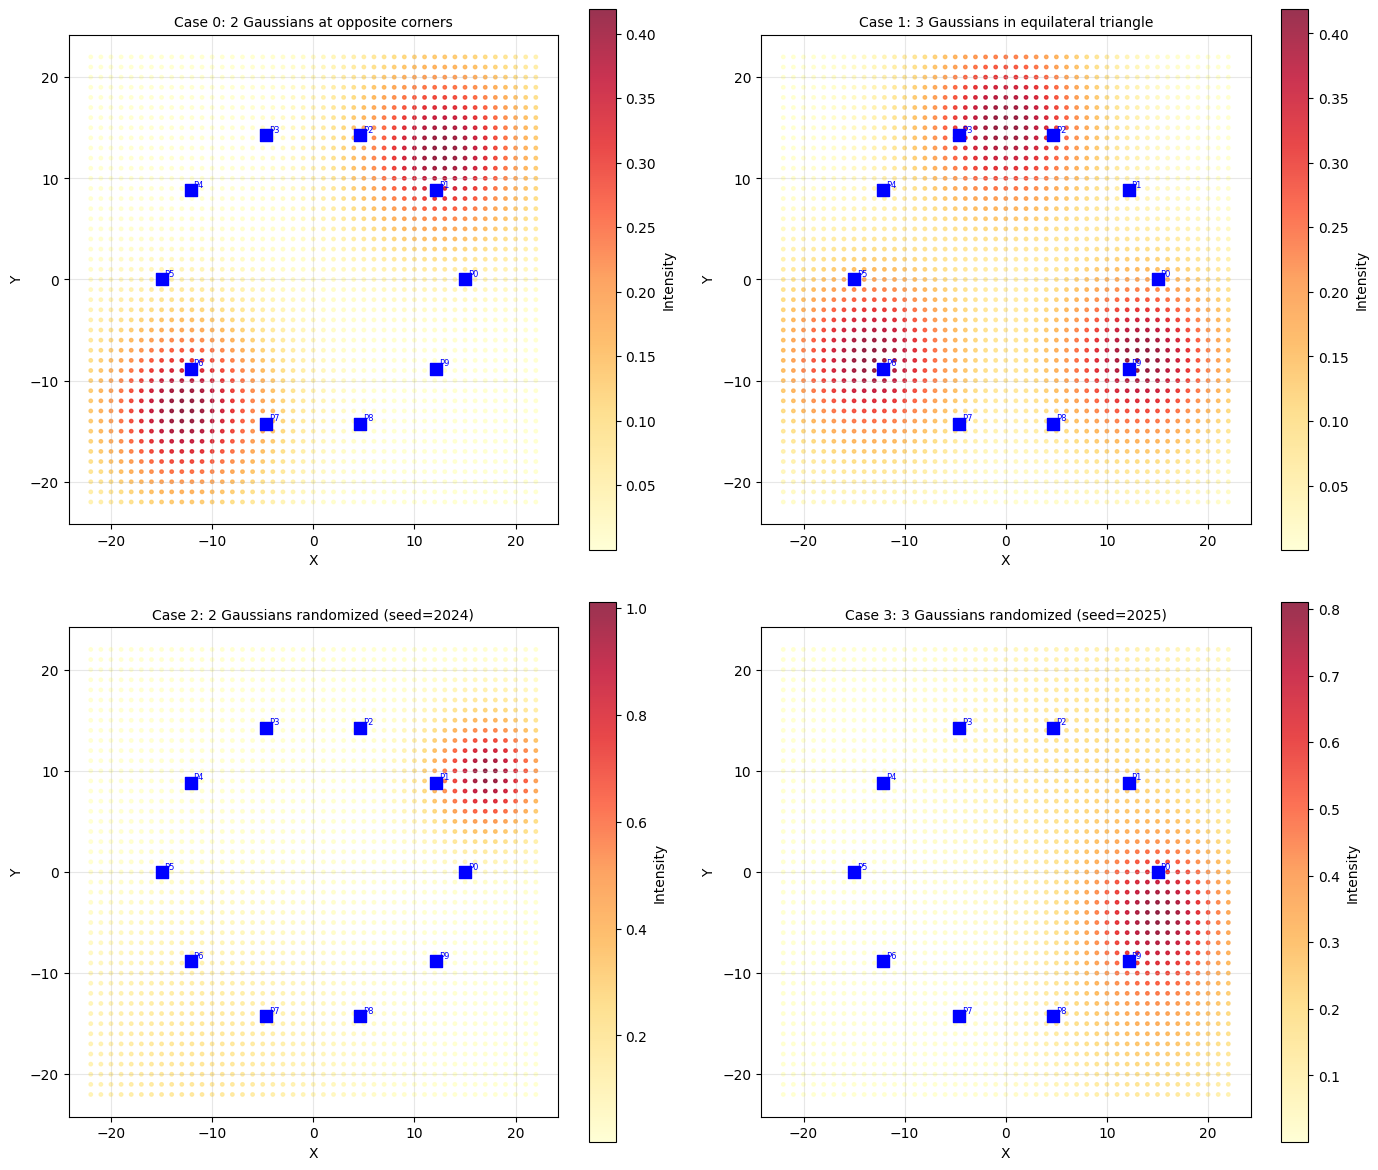

In [105]:
import matplotlib.pyplot as plt

# ── Map & posts (10-hospital decagon) ───────────────────────────────────────
ambulance_posts_gauss = polygon_vertices(10, (0, 0), radius=15)
map_bounds = (-22, 22, -22, 22)
grid_step  = 1

# Pre-generate sample points (fixed across all timesteps)
sample_points = make_grid_points(map_bounds, grid_step)

# J_k: each grid point covered by its nearest ambulance post (computed once)
J_k_gauss = {
    k: [min(range(len(ambulance_posts_gauss)),
            key=lambda j, pt=pt: math.dist(pt, ambulance_posts_gauss[j]))]
    for k, pt in enumerate(sample_points)
}

# ── Visualise all four intensity configurations ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
titles = [
    "Case 0: 2 Gaussians at opposite corners",
    "Case 1: 3 Gaussians in equilateral triangle",
    "Case 2: 2 Gaussians randomized (seed=2024)",
    "Case 3: 3 Gaussians randomized (seed=2025)",
]
xs = [p[0] for p in sample_points]
ys = [p[1] for p in sample_points]

for ax, case, title in zip(axes, range(4), titles):
    intensities = calculate_b_gaussian(ambulance_posts_gauss, case, sample_points, map_bounds)
    sc = ax.scatter(xs, ys, c=intensities, cmap="YlOrRd", s=6, alpha=0.8)
    for idx, post in enumerate(ambulance_posts_gauss):
        ax.scatter(post[0], post[1], c="blue", marker="s", s=80, zorder=5)
        ax.text(post[0] + 0.3, post[1] + 0.3, f"P{idx}", color="blue", fontsize=6)
    plt.colorbar(sc, ax=ax, label="Intensity")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Run the optimisation simulation ─────────────────────────────────────────
def make_calculate_b_gaussian(sample_points, map_bounds):
    """Wrap calculate_b_gaussian into the run_simulation interface."""
    def _fn(ambulance_assignments, ambulance_posts, t):
        return calculate_b_gaussian(ambulance_posts, t, sample_points, map_bounds)
    return _fn

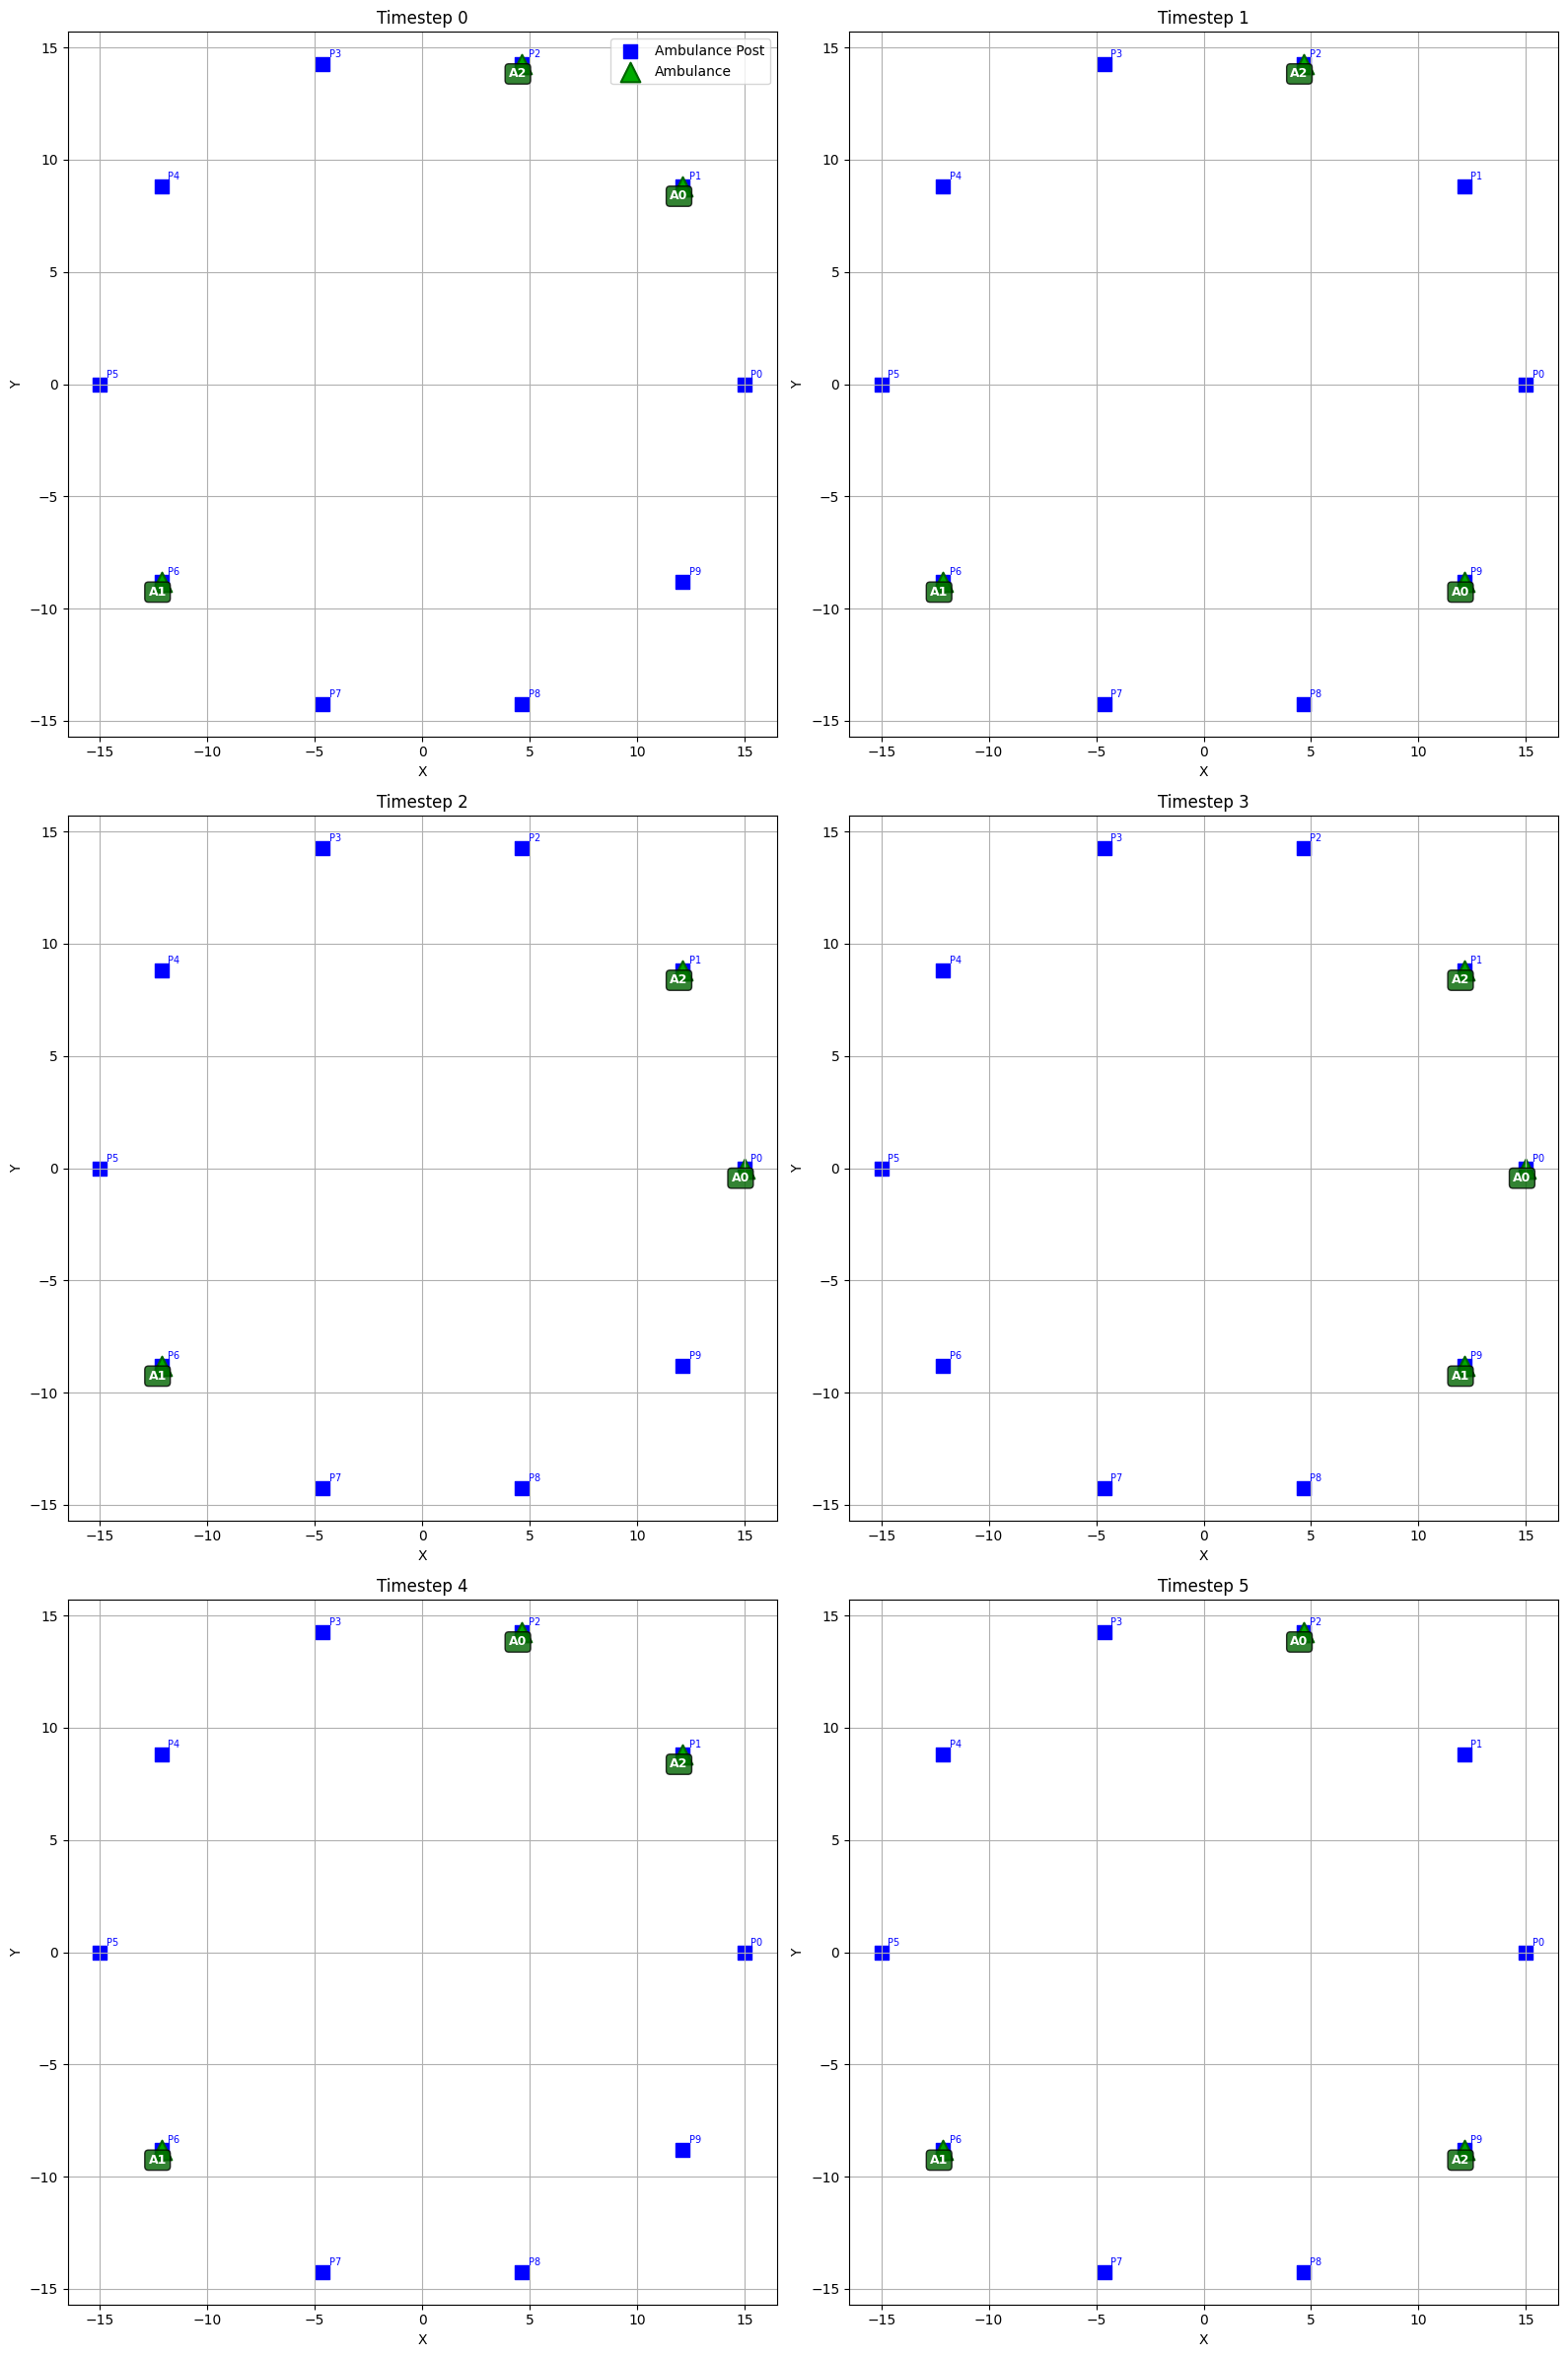

[[(0, 1), (1, 6), (2, 2)],
 [(0, 9), (1, 6), (2, 2)],
 [(0, 0), (1, 6), (2, 1)],
 [(0, 0), (1, 9), (2, 1)],
 [(0, 2), (1, 6), (2, 1)],
 [(0, 2), (1, 6), (2, 9)]]

In [106]:

assignment_history_gauss = run_simulation(
    num_timesteps=6,
    num_ambulances=3,
    ambulance_posts=ambulance_posts_gauss,
    call_hotspots=sample_points,
    J_k=J_k_gauss,
    calculate_c_fn=calculate_c,
    calculate_b_fn=make_calculate_b_gaussian(sample_points, map_bounds),
    show_hotspots=False,  # too many points to plot as hotspots
)
assignment_history_gauss